# Week 1 · Notebook 1 — Optimization Problems, Black Boxes and No Free Lunch

**Goals**
- Define continuous and combinatorial optimisation problems precisely, and the *black-box* setting in which
  metaheuristics are compared: the only cost is the number of objective evaluations.
- Measure, not just assert, why exact methods fail at scale: count the operations of the Held–Karp dynamic programme
  exactly and extrapolate.
- Pin down what the word *metaheuristic* means (Glover 1986; Osman & Laporte 1996; Sörensen & Glover 2013; Sörensen 2015).
- State the No Free Lunch theorem (Wolpert & Macready 1997) precisely and **verify it exhaustively** on every function
  $f:\{0,1\}^3\to\{0,1,2\}$ ($3^8 = 6561$ functions) for five different deterministic, adaptive, non-revisiting algorithms.
- Verify the *sharpened* NFL (Schumacher, Vose & Whitley 2001): NFL holds on a set of functions iff the set is
  closed under permutation — and watch it break on a structured class.

**Prerequisites:** probability (distributions, expectations), basic complexity theory (P, NP, NP-hardness), NumPy.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt
from utils import set_style, savefig, check_close, check_true
set_style()
rng = np.random.default_rng(0)
import itertools
import math
from collections import Counter
from utils import random_euclidean_tsp, tour_length, held_karp, PALETTE

## 1. Optimisation problems

An **optimisation problem** is a pair $(S, f)$ with a search space $S$ and an objective $f: S \to \mathbb{R}$; we
seek $x^\ast \in \arg\min_{x \in S} f(x)$ (maximisation is minimisation of $-f$).

| | Continuous | Combinatorial |
|---|---|---|
| Search space | $S \subseteq \mathbb{R}^d$, usually a box $[\ell, u]^d$ | finite (but huge) $S$: bit strings, permutations, subsets |
| Example | Rastrigin, neural-network hyperparameters | TSP: $(n-1)!/2$ tours; knapsack: $2^n$ subsets |
| Local structure | metric/topology of $\mathbb{R}^d$, possibly gradients | only what a *neighbourhood* $N(x)$ provides |
| "Solved" means | $f(x) - f^\ast \le \varepsilon$ for a target precision $\varepsilon$ | $f(x) = f^\ast$ (or a proven gap) |

**Black-box setting.** The algorithm may query $x \mapsto f(x)$ and nothing else — no gradients, no algebraic form.
This models simulators, trained models, compiled programs, or a validation-loss evaluation in hyperparameter
optimisation and neural architecture search, where one query may cost minutes of GPU time. The natural cost measure
is therefore the **number of function evaluations** (FEs), and every comparison in this course is made at an
**equal evaluation budget** $B$. Wall-clock time depends on implementation language and hardware; FEs do not.

## 2. Why exact methods fail at scale — measured

The symmetric TSP is NP-hard (its decision version is NP-complete; Karp 1972). The best known worst-case
bound for the general TSP is still that of the **Held–Karp** dynamic programme (Held & Karp 1962; Bellman 1962): with
$C(T, k)$ = shortest path from city 0 through the set $T$ ending in $k \in T$,

$$C(T, k) = \min_{j \in T \setminus \lbrace k\rbrace} \big[C(T\setminus\lbrace k\rbrace, j) + D_{jk}\big],$$

which costs $\Theta(n^2 2^n)$ time and $\Theta(n 2^n)$ memory — exponentially better than the $(n-1)!/2$ tours of
enumeration, and still hopeless for $n \approx 50$. We first validate `utils.held_karp` against brute-force
enumeration (an independent method), then measure its growth.

In [2]:
def brute_force_tsp(D):
    """Enumerate all (n-1)! tours that start at city 0 (independent reference for Held-Karp)."""
    n = len(D)
    best = np.inf
    for p in itertools.permutations(range(1, n)):
        L = tour_length((0,) + p, D)
        best = min(best, L)
    return best

for n in (6, 8, 9):
    _, D = random_euclidean_tsp(n, rng)
    hk_len, hk_tour = held_karp(D)
    check_close(hk_len, brute_force_tsp(D), f"Held-Karp = brute force (n={n})", atol=1e-9)
    check_close(tour_length(hk_tour, D), hk_len, f"returned tour realises the optimum (n={n})", atol=1e-9)

[PASS] Held-Karp = brute force (n=6): got 3.150983, expected 3.150983
[PASS] returned tour realises the optimum (n=6): got 3.150983, expected 3.150983


[PASS] Held-Karp = brute force (n=8): got 3.319099, expected 3.319099
[PASS] returned tour realises the optimum (n=8): got 3.319099, expected 3.319099


[PASS] Held-Karp = brute force (n=9): got 2.093754, expected 2.093754
[PASS] returned tour realises the optimum (n=9): got 2.093754, expected 2.093754


**Counting the work instead of timing it.** Wall-clock time depends on the machine, the interpreter and the load, so
we measure Held–Karp's growth by an exact, machine-independent **operation count**. The implementation in `utils`
performs the forward form of the recursion: for every subset $T \subseteq \lbrace 1, \ldots, n-1\rbrace$, every end
city $k \in T$ and every city $j \notin T$ it tries the *relaxation*
$C(T \cup \lbrace j\rbrace, j) \leftarrow \min\big(\cdot,\, C(T,k) + D_{kj}\big)$, which reads the distance matrix exactly once. Counting subsets of size $s$,

$$R(n) = \sum_{s=1}^{n-1} \binom{n-1}{s}\, s\,(n-1-s) = (n-1)(n-2)\,2^{n-3} = \Theta(n^2 2^n)$$

(differentiate $(1+z)^{m}$ twice, $m = n-1$). Adding the $n-1$ initial reads $D_{0k}$ and the final read $D_{\text{last},0}$,
the code must read single entries of $D$ exactly $R(n) + n$ times. We check this by passing `held_karp` a distance
matrix that counts its own scalar reads — an independent measurement of the code as it actually runs.

In [3]:
class CountingMatrix(np.ndarray):
    """A distance matrix that counts scalar reads D[i, j] (used to measure the work done by held_karp)."""
    reads = 0

    def __getitem__(self, key):
        if isinstance(key, tuple) and len(key) == 2 and all(isinstance(k, (int, np.integer)) for k in key):
            CountingMatrix.reads += 1
        return super().__getitem__(key)

def relaxations(n):
    """Closed form R(n) = (n-1)(n-2) 2^(n-3): number of relaxations C(T,k) + D_kj in Held-Karp."""
    return (n - 1) * (n - 2) * 2 ** (n - 3)

sizes = np.arange(5, 16)
reads = []
for n in sizes:
    _, D = random_euclidean_tsp(int(n), rng)
    CountingMatrix.reads = 0
    held_karp(D.view(CountingMatrix))
    reads.append(CountingMatrix.reads)
reads = np.array(reads)
predicted = np.array([relaxations(int(n)) + int(n) for n in sizes])
print(" n   scalar reads of D    ratio to previous n")
for k, (n, r) in enumerate(zip(sizes, reads)):
    print(f"{n:2d}   {r:17,d}    {'' if k == 0 else f'{r / reads[k - 1]:.3f}'}")
check_true(np.array_equal(reads, predicted), "measured operation count = (n-1)(n-2)2^(n-3) + n for every n (exact)")
beta = np.polyfit(sizes[3:], np.log2(reads[3:] / sizes[3:] ** 2), 1)[0]
print(f"least-squares fit of the counts: R ~ n^2 * {2**beta:.3f}^n  (the ratio R(n+1)/R(n) = 2n/(n-2) -> 2)")

RATE = 1e9   # relaxations per second: an optimistic, compiled, cache-friendly implementation
for n in (20, 30, 50):
    ops = relaxations(n)
    print(f"n={n}: {ops:.3g} relaxations = {ops / RATE:.3g} s at 1e9/s ({ops / RATE / 3.156e7:.3g} years);  "
          f"memory for C(T,k): {n * 2.0 ** (n - 1) * 8 / 1e9:.3g} GB;  tours to enumerate (n-1)!/2 = {math.factorial(n - 1) / 2:.3g}")

 n   scalar reads of D    ratio to previous n
 5                  53    
 6                 166    3.132
 7                 487    2.934
 8               1,352    2.776
 9               3,593    2.658
10               9,226    2.568
11              23,051    2.498
12              56,332    2.444
13             135,181    2.400
14             319,502    2.364
15             745,487    2.333
[PASS] measured operation count = (n-1)(n-2)2^(n-3) + n for every n (exact)
least-squares fit of the counts: R ~ n^2 * 2.058^n  (the ratio R(n+1)/R(n) = 2n/(n-2) -> 2)
n=20: 4.48e+07 relaxations = 0.0448 s at 1e9/s (1.42e-09 years);  memory for C(T,k): 0.0839 GB;  tours to enumerate (n-1)!/2 = 6.08e+16
n=30: 1.09e+11 relaxations = 109 s at 1e9/s (3.45e-06 years);  memory for C(T,k): 129 GB;  tours to enumerate (n-1)!/2 = 4.42e+30
n=50: 3.31e+17 relaxations = 3.31e+08 s at 1e9/s (10.5 years);  memory for C(T,k): 2.25e+08 GB;  tours to enumerate (n-1)!/2 = 3.04e+62


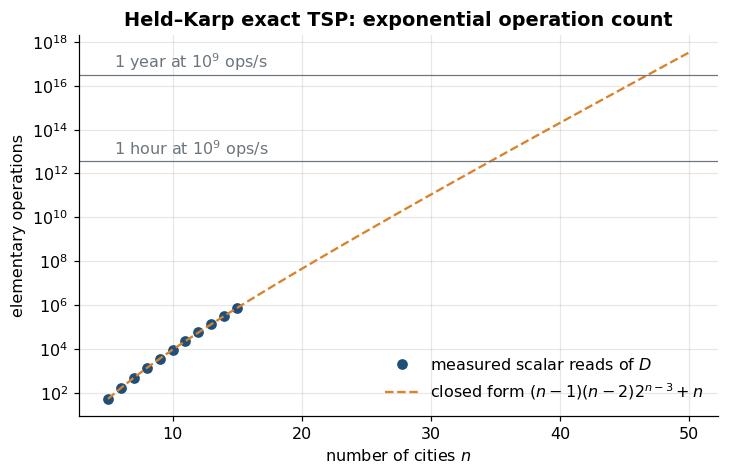

In [4]:
fig, ax = plt.subplots()
ax.semilogy(sizes, reads, "o", color=PALETTE["blue"], label="measured scalar reads of $D$")
nn = np.arange(5, 51)
ax.semilogy(nn, [relaxations(int(n)) + int(n) for n in nn], "--", color=PALETTE["orange"],
            label=r"closed form $(n-1)(n-2)2^{n-3} + n$")
for secs, lab in ((3600, "1 hour"), (3.156e7, "1 year")):
    ax.axhline(RATE * secs, color=PALETTE["grey"], lw=0.8)
    ax.text(5.5, RATE * secs * 2, f"{lab} at $10^9$ ops/s", color=PALETTE["grey"])
ax.set(xlabel="number of cities $n$", ylabel="elementary operations",
       title="Held–Karp exact TSP: exponential operation count")
ax.legend()
savefig("w1_held_karp_growth.png"); plt.show()

The count doubles (times $n/(n-2)$) with every added city, exactly as the $\Theta(n^2 2^n)$ analysis predicts; even at
an optimistic $10^9$ relaxations per second, $n = 50$ needs about a decade and $2 \times 10^{8}$ GB of table, so exact
dynamic programming is out of reach long before instance sizes that matter in practice. (Branch-and-cut codes
such as Concorde solve far larger *Euclidean* instances by exploiting LP relaxations, but offer no worst-case
guarantee better than exponential.) This is the regime in which we trade optimality guarantees for good solutions
within a budget.

## 3. What is a metaheuristic?

- **Glover (1986)** coined *meta-heuristic* for tabu search: a master strategy that guides and modifies
  subordinate heuristics to go beyond local optimality.
- **Osman & Laporte (1996):** "an iterative generation process which guides a subordinate heuristic by combining
  intelligently different concepts for exploring and exploiting the search space; learning strategies are used to
  structure information in order to find efficiently near-optimal solutions."
- **Sörensen & Glover (2013):** "a high-level problem-independent algorithmic framework that provides a set of
  guidelines or strategies to develop heuristic optimization algorithms." The same word also names concrete
  problem-specific implementations of such a framework.
- **Sörensen (2015), "Metaheuristics — the metaphor exposed":** a critique of "novel" methods that re-label known
  mechanisms with a natural metaphor. This course follows his prescription: every algorithm is described by its
  **mechanisms** — representation, neighbourhood/variation operator, selection/acceptance rule, memory, and source of
  stochasticity — and the metaphor is only a mnemonic.

Abstractly, a (possibly stochastic) black-box search algorithm is a map from the history of evaluated pairs to
the next query:

$$a: \; d_m = \big((x_1, f(x_1)), \ldots, (x_m, f(x_m))\big) \;\mapsto\; x_{m+1} \in S .$$

## 4. The No Free Lunch theorem

**Setting (Wolpert & Macready 1997).** $X$ and $Y$ are finite, $\mathcal{F} = Y^X$ is the set of *all* functions.
A deterministic algorithm $a$ is *non-revisiting* if $x_{m+1} \notin \lbrace x_1, \ldots, x_m\rbrace$. Let
$d^y_m = (f(x_1), \ldots, f(x_m))$ be the sequence of observed values; any performance measure
$\Phi(d^y_m)$ (best-so-far, time to hit a target, ...) is a function of $d^y_m$.

**Theorem (NFL).** For any two algorithms $a_1, a_2$ and any $m \le |X|$,

$$\sum_{f \in \mathcal{F}} P(d^y_m \mid f, m, a_1) = \sum_{f \in \mathcal{F}} P(d^y_m \mid f, m, a_2).$$

*Proof sketch (induction on $m$).* For $m = 1$, $x_1$ is fixed by $a$ and, as $f$ ranges over $\mathcal{F}$,
$f(x_1)$ takes each value in $Y$ exactly $|Y|^{|X|-1}$ times. Given a history $d_m$, the next point $x_{m+1}$ is
*new*, and among all $f$ consistent with $d_m$ the value $f(x_{m+1})$ is again uniform on $Y$, independently of
which new point was chosen. Hence the count of functions producing any value sequence is
$|Y|^{|X|-m}$, independent of $a$. $\square$

The proof gives a **closed form** we can check: for every algorithm, every $y \in Y^m$ occurs for exactly
$|Y|^{|X|-m}$ functions. Averaged uniformly over all functions, performance cannot differ. Stochastic algorithms
are mixtures of deterministic ones, so the result extends to them.

In [5]:
NBITS = 3
NX, NY = 2**NBITS, 3
HAM = np.array([[bin(a ^ b).count("1") for b in range(NX)] for a in range(NX)])
ALL_F = np.array(list(itertools.product(range(NY), repeat=NX)))  # every f: {0,1}^3 -> {0,1,2}
print("number of functions |Y|^|X| =", len(ALL_F))

# ---- five deterministic, non-revisiting algorithms: history (xs, ys) -> next point
def unvisited(xs):
    return [x for x in range(NX) if x not in xs]

def alg_lexicographic(xs, ys):
    return unvisited(xs)[0]

def alg_gray_order(xs, ys):
    order = [g ^ (g >> 1) for g in range(NX)]         # walk along the reflected Gray code
    return [x for x in order if x not in xs][0]

def alg_greedy_local(xs, ys):
    """Adaptive: the unvisited point closest (Hamming) to the best point seen so far."""
    if not xs:
        return 0
    b = xs[int(np.argmin(ys))]
    return min(unvisited(xs), key=lambda x: (HAM[b, x], x))

def alg_anti_local(xs, ys):
    """Adaptive: the unvisited point farthest from the best point seen so far."""
    if not xs:
        return 0
    b = xs[int(np.argmin(ys))]
    return min(unvisited(xs), key=lambda x: (-HAM[b, x], x))

def alg_history_hash(xs, ys):
    """Adaptive and 'random-looking': the choice is a pseudo-random but deterministic function of the history."""
    cand = unvisited(xs)
    r = np.random.default_rng([len(ys), *ys, 12345])
    return cand[int(r.integers(len(cand)))]

ALGS = {"lexicographic": alg_lexicographic, "gray order": alg_gray_order, "greedy local": alg_greedy_local,
        "anti local": alg_anti_local, "history hash": alg_history_hash}

def run(alg, f, m=NX):
    xs, ys = [], []
    for _ in range(m):
        x = alg(xs, ys)
        assert x not in xs, "algorithm revisited a point"
        xs.append(x); ys.append(int(f[x]))
    return tuple(ys)

SEQS = {name: np.array([run(a, f) for f in ALL_F]) for name, a in ALGS.items()}
print(f"ran {len(ALGS)} algorithms on all {len(ALL_F)} functions ({len(ALGS) * len(ALL_F) * NX} evaluations)")

number of functions |Y|^|X| = 6561


ran 5 algorithms on all 6561 functions (262440 evaluations)


**Exhaustive verification.** For every prefix length $m = 1, \ldots, 8$ we compare the *multisets* of value
sequences $d^y_m$ produced over all 6561 functions: (i) between every pair of algorithms (the theorem), and (ii) with
the closed form "every $y \in Y^m$ appears exactly $3^{8-m}$ times" (the proof), which implies that the mean
best-so-far equals that of $m$ i.i.d. uniform draws, $\mathbb{E}[\min] = (2/3)^m + (1/3)^m$. The algorithms genuinely differ:
we also count on how many functions they visit points in a different order.

In [6]:
names = list(ALGS)
for m in range(1, NX + 1):
    counters = {k: Counter(map(tuple, SEQS[k][:, :m])) for k in names}
    closed_form = all(len(cn) == NY**m and set(cn.values()) == {NY ** (NX - m)} for cn in counters.values())
    pairwise = all(counters[names[0]] == counters[k] for k in names[1:])
    check_true(closed_form and pairwise,
               f"m={m}: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^{NX - m} times")

differ = np.mean([np.any(SEQS["greedy local"][i] != SEQS["lexicographic"][i]) for i in range(len(ALL_F))])
print(f"...although greedy-local and lexicographic observe different value sequences on {100 * differ:.1f}% of functions")

# closed form: under NFL the observed values behave like m i.i.d. uniform draws from {0,1,2}, so
# E[min] = sum_{k>=1} P(min >= k) = (2/3)^m + (1/3)^m
m_grid = np.arange(1, NX + 1)
iid_min = (2 / 3) ** m_grid + (1 / 3) ** m_grid
best_all = {k: np.minimum.accumulate(SEQS[k], axis=1).mean(axis=0) for k in names}
for k in names:
    check_close(best_all[k], iid_min, f"mean best-so-far curve of {k} = (2/3)^m + (1/3)^m", atol=1e-12)

[PASS] m=1: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^7 times


[PASS] m=2: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^6 times
[PASS] m=3: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^5 times


[PASS] m=4: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^4 times


[PASS] m=5: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^3 times


[PASS] m=6: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^2 times


[PASS] m=7: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^1 times


[PASS] m=8: all 5 algorithms induce the same distribution of d^y_m; each sequence occurs 3^0 times
...although greedy-local and lexicographic observe different value sequences on 84.3% of functions
[PASS] mean best-so-far curve of lexicographic = (2/3)^m + (1/3)^m: got [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171], expected [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171]
[PASS] mean best-so-far curve of gray order = (2/3)^m + (1/3)^m: got [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171], expected [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171]
[PASS] mean best-so-far curve of greedy local = (2/3)^m + (1/3)^m: got [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171], expected [1.       0.555556 0.333333 0.209877 0.135802 0.089163 0.058985 0.039171]
[PASS] mean best-so-far curve of anti local = (2/3)^m + (1/3)^m: got [1.       0.555556 0.333333 0.209877 0.135802 0

## 5. Sharpened NFL: closure under permutation

**Theorem (Schumacher, Vose & Whitley 2001).** For a set $F \subseteq Y^X$, the NFL equality holds for all pairs of
algorithms **iff** $F$ is *closed under permutation* (c.u.p.): $f \in F \Rightarrow f \circ \sigma \in F$ for every
bijection $\sigma: X \to X$.

The orbit of a single function under all $8! = 40320$ permutations is c.u.p. (it is exactly the set of functions with
the same *histogram* of values). A structured class — here the **Hamming-Lipschitz** functions with
$|f(x) - f(x')| \le 1$ whenever $x, x'$ differ in one bit — is not, and on such a class algorithms that exploit
locality can win. Igel & Toussaint (2003) showed that c.u.p. sets are a vanishing fraction of all subsets: here the
c.u.p. sets are unions of histogram-orbits, so there are $2^{\#\text{orbits}} - 1$ non-empty ones out of
$2^{6561} - 1$.

In [7]:
perms = np.array(list(itertools.permutations(range(NX))))
f0 = np.array([0, 1, 1, 2, 2, 2, 2, 2])
orbit = np.unique(f0[perms], axis=0)
same_hist = ALL_F[np.all(np.sort(ALL_F, axis=1) == np.sort(f0), axis=1)]
check_close(len(orbit), math.factorial(8) // (math.factorial(1) * math.factorial(2) * math.factorial(5)),
            "orbit size = multinomial 8!/(1!2!5!)", atol=0)
check_true(np.array_equal(orbit, np.unique(same_hist, axis=0)), "orbit of f0 = all functions with f0's value histogram")

def violates_cup(F):
    """True if some f in F and some permutation p (a deterministic sample of 416 of the 8!) give f o p outside F.

    Exhibiting one such pair is a complete proof that F is not closed under permutation."""
    Fset = set(map(tuple, F))
    return any(tuple(f[p]) not in Fset for f in F for p in perms[::97])

def seq_counter(name, mask, m):
    return Counter(map(tuple, SEQS[name][mask, :m]))

in_orbit = np.all(np.sort(ALL_F, axis=1) == np.sort(f0), axis=1)
smooth = np.array([all(abs(int(f[a]) - int(f[b])) <= 1 for a in range(NX) for b in range(NX) if HAM[a, b] == 1)
                   for f in ALL_F])
n_orbits = len(np.unique(np.sort(ALL_F, axis=1), axis=0))
print(f"Hamming-Lipschitz functions: {smooth.sum()} of {len(ALL_F)};  histogram orbits: {n_orbits} "
      f"-> {2**n_orbits - 1:.3e} non-empty c.u.p. subsets vs 2^6561 - 1 subsets")
check_close(n_orbits, math.comb(NX + NY - 1, NY - 1), "number of orbits = compositions of 8 into 3 parts", atol=0)

orbit_nfl = all(seq_counter(k, in_orbit, m) == seq_counter("lexicographic", in_orbit, m)
                for k in names for m in range(1, NX + 1))
check_true(orbit_nfl, "NFL holds on the (c.u.p.) orbit of f0 for all 5 algorithms and all m")
check_true(violates_cup(ALL_F[smooth]), "the Hamming-Lipschitz class is NOT closed under permutation")
smooth_nfl = all(seq_counter(k, smooth, m) == seq_counter("lexicographic", smooth, m)
                 for k in names for m in range(1, NX + 1))
check_true(not smooth_nfl, "NFL fails on the Hamming-Lipschitz class (performance distributions differ)")

[PASS] orbit size = multinomial 8!/(1!2!5!): got 168, expected 168
[PASS] orbit of f0 = all functions with f0's value histogram
Hamming-Lipschitz functions: 743 of 6561;  histogram orbits: 45 -> 3.518e+13 non-empty c.u.p. subsets vs 2^6561 - 1 subsets
[PASS] number of orbits = compositions of 8 into 3 parts: got 45, expected 45


[PASS] NFL holds on the (c.u.p.) orbit of f0 for all 5 algorithms and all m
[PASS] the Hamming-Lipschitz class is NOT closed under permutation
[PASS] NFL fails on the Hamming-Lipschitz class (performance distributions differ)


In [8]:
print("mean best-so-far after m evaluations on the Hamming-Lipschitz class (exact, exhaustive):")
print("m               " + "  ".join(f"{m:5d}" for m in range(1, NX + 1)))
best_smooth, best_rest = {}, {}
for k in names:
    best_smooth[k] = np.minimum.accumulate(SEQS[k][smooth], axis=1).mean(axis=0)
    best_rest[k] = np.minimum.accumulate(SEQS[k][~smooth], axis=1).mean(axis=0)
    print(f"{k:15s} " + "  ".join(f"{v:5.3f}" for v in best_smooth[k]))

# conservation: because the all-function totals are identical (verified above), any advantage an algorithm has over
# another on the class is repaid exactly on its complement. This is an algebraic consequence of NFL, so we print it
# rather than "check" it.
ns, nr = smooth.sum(), (~smooth).sum()
print("\ntotal advantage over lexicographic (sum over functions and m = 1..8 of the best-so-far difference):")
for k in names[1:]:
    adv_class = (best_smooth["lexicographic"] - best_smooth[k]).sum() * ns
    adv_rest = (best_rest["lexicographic"] - best_rest[k]).sum() * nr
    print(f"{k:15s} on the class {adv_class:+8.1f}   on the complement {adv_rest:+8.1f}")

mean best-so-far after m evaluations on the Hamming-Lipschitz class (exact, exhaustive):
m                   1      2      3      4      5      6      7      8
lexicographic   1.000  0.720  0.580  0.497  0.439  0.398  0.369  0.346
gray order      1.000  0.720  0.580  0.497  0.439  0.398  0.369  0.346
greedy local    1.000  0.720  0.556  0.458  0.415  0.390  0.363  0.346
anti local      1.000  0.696  0.585  0.521  0.480  0.423  0.380  0.346
history hash    1.000  0.744  0.598  0.524  0.441  0.398  0.366  0.346

total advantage over lexicographic (sum over functions and m = 1..8 of the best-so-far difference):
gray order      on the class     +0.0   on the complement     +0.0
greedy local    on the class    +75.0   on the complement    -75.0
anti local      on the class    -61.0   on the complement    +61.0
history hash    on the class    -51.0   on the complement    +51.0


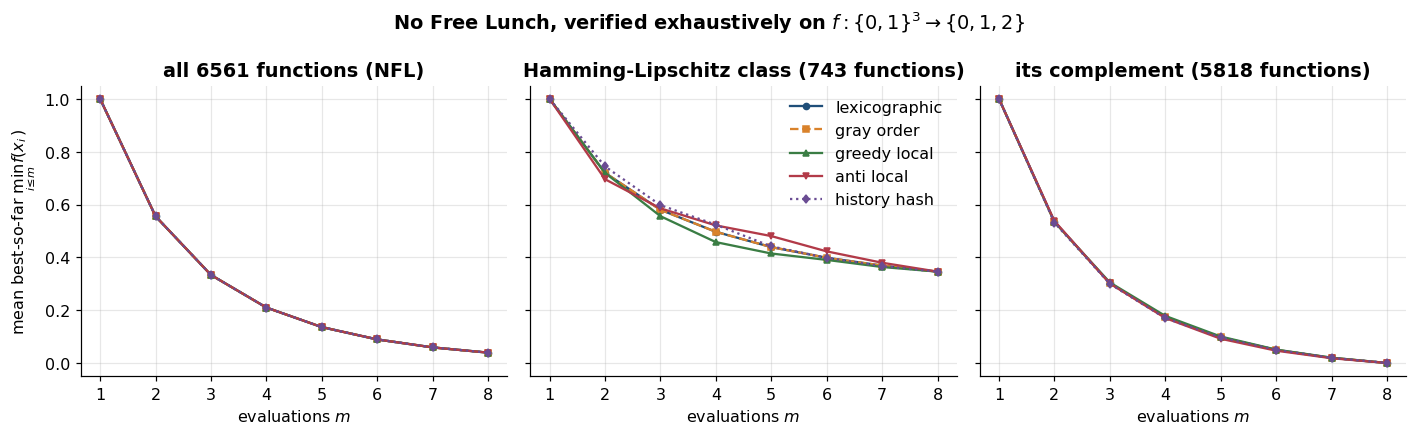

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
ms = np.arange(1, NX + 1)
styles = dict(zip(names, ["-o", "--s", "-^", "-v", ":d"]))
for ax, (title, curves) in zip(axes, [("all 6561 functions (NFL)", best_all),
                                       (f"Hamming-Lipschitz class ({ns} functions)", best_smooth),
                                       (f"its complement ({nr} functions)", best_rest)]):
    for k in names:
        ax.plot(ms, curves[k], styles[k], ms=4, label=k)
    ax.set(title=title, xlabel="evaluations $m$")
axes[0].set_ylabel("mean best-so-far $\\min_{i\\leq m} f(x_i)$")
axes[1].legend()
fig.suptitle("No Free Lunch, verified exhaustively on $f:\\{0,1\\}^3\\to\\{0,1,2\\}$", fontweight="bold")
fig.tight_layout()
savefig("w1_nfl_exhaustive.png"); plt.show()

In [10]:
gap = best_smooth["anti local"] - best_smooth["greedy local"]
m_star = int(np.argmax(gap)) + 1
print(f"largest advantage of greedy-local over anti-local on the smooth class: {gap.max():.3f} at m={m_star}")
check_true(gap.max() > 0, "on the smooth class greedy-local has a strictly better mean best-so-far than anti-local for some m")

largest advantage of greedy-local over anti-local on the smooth class: 0.066 at m=5
[PASS] on the smooth class greedy-local has a strictly better mean best-so-far than anti-local for some m


## 6. Why NFL does not make algorithm design pointless

- NFL averages **uniformly over all functions**. A uniformly random $f \in Y^X$ is incompressible noise with no
  exploitable structure; real problems (tour lengths obeying the triangle inequality, smooth loss surfaces, schedules
  with local cost interactions) are not like that.
- The sharpened NFL says exactly which averages are "free-lunch-less": those over c.u.p. classes. Any class defined
  by a *locality* property (Lipschitz, bounded description length, few local optima) is not c.u.p., and on it an
  algorithm matched to the structure can win — here exact, exhaustive numbers show the greedy-local algorithm ahead
  of anti-local on Hamming-Lipschitz functions, and the conservation identity shows the price: it loses by exactly as
  much, in aggregate, on the complement (the optimisation analogue of Schaffer's 1994 conservation law for
  generalisation performance).
- Consequence for the course: an algorithm is only good **relative to a problem class**. Weeks 2–6 therefore state
  which structure each mechanism exploits (correlated neighbourhoods, building blocks, population gradients,
  pheromone-encoded edge statistics), and benchmark on explicitly described classes (Notebook 3 measures that
  structure; the Lab builds the benchmarking harness).
- The same logic underlies meta-learning and AutoML: tuning a hyperparameter optimiser on a distribution of tasks
  is justified precisely because that distribution is far from c.u.p.

Further NFL results: Wolpert & Macready (2005) on co-evolutionary free lunches; Auger & Teytaud (2010) on continuous
domains, where NFL in its naive form fails because no uniform measure over all functions exists.

## Key takeaways
- Metaheuristics are compared in the black-box model by **function evaluations**, at equal budgets.
- Exact algorithms scale exponentially: Held–Karp's measured operation count equals $(n-1)(n-2)2^{n-3} + n$
  exactly, which puts $n=50$ out of reach and motivates approximate search.
- A metaheuristic is a problem-independent *framework* (Sörensen & Glover 2013); we describe each one by mechanisms,
  not metaphors.
- NFL (Wolpert & Macready 1997) was verified exhaustively: five different adaptive algorithms induce exactly the same
  distribution of value sequences over all 6561 functions, each sequence occurring $3^{8-m}$ times.
- The sharpened NFL (Schumacher et al. 2001) holds on c.u.p. sets and fails on structured classes; performance gains
  on a class are exactly repaid on its complement.

## Exercises
1. ★ Prove that the orbit $\lbrace f\circ\sigma\rbrace$ of a function under all permutations of $X$ equals the set of
   functions with the same value histogram, and derive its size as a multinomial coefficient.
2. ★ Show that a revisiting algorithm can be *strictly worse* than a non-revisiting one when performance is measured
   per evaluation, and explain why NFL is stated for non-revisiting algorithms.
3. ★★ Extend the exhaustive verification to a *stochastic* algorithm (uniformly random order of the unvisited
   points) by computing its exact distribution of $d^y_m$ as a mixture over the $8!$ deterministic orders.
4. ★★ Prove the "only if" direction of the sharpened NFL for a two-point space $X = \lbrace a, b\rbrace$: construct,
   for any non-c.u.p. $F$, two algorithms with different performance distributions on $F$.
5. ★★ Measure the *wall-clock* time of `held_karp` for $n = 5, \ldots, 15$ and fit both $c\,n^2 2^n$ and $c\,2^{\beta n}$
   (least squares on $\log t$); use a model-selection criterion to decide which fits better, estimate the time per
   relaxation, explain why the notebook uses operation counts rather than timings, and state what the memory
   footprint implies for $n=25$.
6. ★★★ Design a class of functions on $\lbrace 0,1\rbrace^4$ defined by a structural property of your choice (e.g.
   unimodality under bit flips) and find, by exhaustive search over a family of adaptive algorithms, the algorithm
   that minimises expected evaluations to the optimum on that class. Report how much it loses on the complement.